## Fase 1: Construyendo el Multiverso del Jugador (Min. 4 Dimensiones)

Pregunta de control:

> Antes de medir cualquier distancia, ¿qué operación de la Unidad II deben aplicarle obligatoriamente a estas 4 columnas para que los Minutos_Jugados (rango en miles) no aplasten matemáticamente a los Goles (rango en decenas)? Apliquen esa transformación en el código.

Antes de cualquier cosa se tiene que estandarizar las caracteristicas, ya que los m inutos jugados pueden estar en miles, miesntras que los goles pueden estar en decenas.

In [5]:

import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/mricardo89/data-mining/main/Unit-III/datasets/players_data-2025_2026.csv"

df = pd.read_csv(url)

df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,24.0,2000.0,37,30,...,3,0,0,20,51,5,37,17,27,0
1,2,Jerome Abbey,eng ENG,MF,Wolves,eng Premier League,15.0,2009.0,1,0,...,0,0,0,0,0,1,0,1,0,0
2,3,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,3,2,...,0,0,0,3,1,0,3,2,4,0
3,4,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,19.0,2006.0,22,4,...,0,0,0,7,3,2,30,3,3,0
4,5,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,25.0,1999.0,8,1,...,1,0,0,3,0,0,1,2,1,0


In [14]:
df.describe()

,Rk,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
count,2839.000000,2837.000000,2837.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,...,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000
mean,1420.000000,24.855834,1999.802256,19.138781,13.576611,1218.580134,13.539803,1.660444,1.159211,2.819655,...,2.412821,0.121169,0.041564,14.497710,13.752730,2.060937,21.657978,10.141951,11.924974,0.045791
std,819.693032,4.623789,4.633160,11.520385,11.225366,963.218994,10.703241,2.932688,1.833065,4.134442,...,2.526406,0.352339,0.204853,13.493894,14.665142,3.801657,34.963118,11.810994,12.430342,0.228399
min,1.000000,15.000000,1983.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,710.500000,21.000000,1997.000000,9.000000,3.000000,320.500000,3.600000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
50%,1420.000000,25.000000,2000.000000,20.000000,12.000000,1074.000000,11.900000,0.000000,0.000000,1.000000,...,2.000000,0.000000,0.000000,12.000000,9.000000,1.000000,6.000000,5.000000,8.000000,0.000000
75%,2129.500000,28.000000,2003.000000,29.000000,23.000000,1972.500000,21.900000,2.000000,2.000000,4.000000,...,4.000000,0.000000,0.000000,23.000000,20.000000,2.500000,26.500000,16.000000,19.000000,0.000000
max,2839.000000,41.000000,2010.000000,38.000000,38.000000,3420.000000,38.000000,36.000000,21.000000,41.000000,...,13.000000,3.000000,2.000000,87.000000,118.000000,41.000000,295.000000,77.000000,72.000000,2.000000


In [16]:
df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,24.0,2000.0,37,30,...,3,0,0,20,51,5,37,17,27,0
1,2,Jerome Abbey,eng ENG,MF,Wolves,eng Premier League,15.0,2009.0,1,0,...,0,0,0,0,0,1,0,1,0,0
2,3,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,3,2,...,0,0,0,3,1,0,3,2,4,0
3,4,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,19.0,2006.0,22,4,...,0,0,0,7,3,2,30,3,3,0
4,5,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,25.0,1999.0,8,1,...,1,0,0,3,0,0,1,2,1,0


In [15]:
estrella = df.loc[df['Gls'].idxmax()]
print(estrella)

Rk                 1320
Player       Harry Kane
Nation          eng ENG
Pos               FW,MF
Squad     Bayern Munich
              ...      
Off                  20
Crs                  12
Int                   8
TklW                 13
OG                    0
Name: 1319, Length: 102, dtype: object


In [19]:
features = ['Gls', 'Ast', 'Min', 'Sh']

X = df[features].copy()
X.head()

,Gls,Ast,Min,Sh
0,4,5,2449,47
1,0,0,17,0
2,0,0,164,0
3,2,0,681,17
4,0,0,138,4


In [20]:
mean_values = X.mean()
std_values = X.std()

standard = (X - mean_values) / std_values   
print(standard.head())

        Gls       Ast       Min        Sh
0  0.797752  2.095283  1.277404  1.670891
1 -0.566185 -0.632390 -1.247463 -0.823119
2 -0.566185 -0.632390 -1.094850 -0.823119
3  0.115783 -0.632390 -0.558108  0.078970
4 -0.566185 -0.632390 -1.121843 -0.610862


In [27]:
estrella = df['Gls'].idxmax()
vector = standard.loc[estrella].to_numpy()
print("Vector:", vector)

Vector: [11.70924343  2.09528301  1.20265472  5.49150054]


In [29]:
info = df.drop(index=estrella)
candidato = standard.drop(index=estrella).to_numpy()
nombre = info['Player'].to_numpy()

## Fase 2: El Duelo de Distancias (Euclidiana vs. Manhattan)

> Análisis Crítico: ¿El algoritmo sugirió al mismo jugador en ambos casos? Como ingenieros, expliquen en un bloque de Markdown las diferencias observables entre la Distancia Euclidiana comparado con la Distancia Manhattan.

La distancia Euclidiana mide la distancia entre dos jugadores en el espacio multidimensional, mientras que la distancia manhattan suma las diferencias absolutas de cada caracteristica.

Si las dos dos seleccionarion al mismo jugador, eso significa que el jugador presenta un comportamiento similar al jugador estrella. Si es diferente eso significa que puede afectar la seleccion del jugador estrella.

In [35]:
distancia_euclidiana = np.sqrt(np.sum((candidato - vector) ** 2, axis=1))

remplazo = nombre[np.argmin(distancia_euclidiana)]

print("Estrella:", df.loc[estrella]["Player"])
print("El jugador más parecido a la estrella es:", remplazo)
print("Distancia Euclidiana:", np.min(distancia_euclidiana))

Estrella: Harry Kane
El jugador más parecido a la estrella es: Erling Haaland
Distancia Euclidiana: 3.5485104980153936


In [40]:
def manhattan(a,b):
    return np.sum(np.abs(a-b))

manhattan = np.array([manhattan(estrella, candidato) for candidato in candidato])

cercano = np.argmin(manhattan)
reemplazo_manhattan = nombre[cercano]

print("Estrella:", df.loc[estrella]["Player"])
print("El jugador más parecido a la estrella es:", reemplazo_manhattan)
print("Distancia Manhatan:", np.min(manhattan))

Estrella: Harry Kane
El jugador más parecido a la estrella es: Erling Haaland
Distancia Manhatan: 5255.964128804323


## Fase 3: El Reto de Visualización en 4D (Investigación Independiente)

Investiguen y elijan una técnica o librería en Python que les permita proyectar visualmente vectores de 4 dimensiones o más en una pantalla 2D.(Pistas que pueden investigar: Gráficos de Radar / Spider Charts, Coordenadas Paralelas, o el uso de color/tamaño como cuartas dimensiones en un Scatter 3D).

Implementen el código para visualizar a su "Jugador Estrella" junto al "Reemplazo Sugerido" y a un "Tercer Jugador Aleatorio" (para ver el contraste).

In [44]:
indice_reemplazo = remplazo
disponibles = df.index[
    (df.index != estrella) &
    (df.index != indice_reemplazo)
]

indice_candidato = np.random.choice(disponibles)
tercer_jugador = df.loc[indice_candidato, "Player"]

print("Estrella:", df.loc[estrella]["Player"])
print("El jugador más parecido a la estrella es:", indice_reemplazo)
print("El tercer jugador es:", tercer_jugador)

Estrella: Harry Kane
El jugador más parecido a la estrella es: Erling Haaland
El tercer jugador es: Alessandro Zanoli


In [54]:
valores_estrella = standard.loc[estrella].to_numpy()
indice_fila_reemplazo = df.index[df["Player"].eq(indice_reemplazo)][0]
valores_reemplazo = standard.loc[indice_fila_reemplazo].to_numpy()
valores_random = standard.loc[indice_candidato].to_numpy()

angulos = np.linspace(0, 2* np.pi, len(features), endpoint=False)
angulos = np.concatenate((angulos, [angulos[0]]))

In [55]:
estrella_plot = np.concatenate((valores_estrella, [valores_estrella[0]]))
reemplazo_plot = np.concatenate((valores_reemplazo, [valores_reemplazo[0]]))
random_plot = np.concatenate((valores_random, [valores_random[0]]))

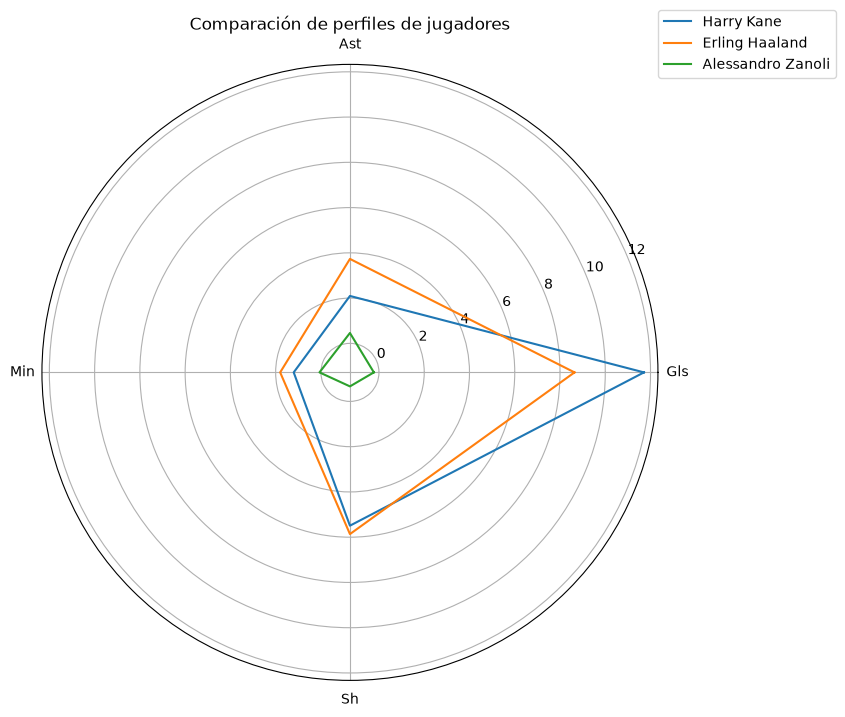

In [58]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

ax.plot(
    angulos,
    estrella_plot,
    label=df.loc[estrella, 'Player']
)

ax.plot(
    angulos,
    reemplazo_plot,
    label=df.loc[indice_fila_reemplazo, 'Player']
)

ax.plot(
    angulos,
    random_plot,
    label=df.loc[indice_candidato, 'Player']
)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(features)

ax.set_title("Comparación de perfiles de jugadores")

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.3, 1.1)
)

plt.show()